In [1]:
# Import libraries we need for the project
import pandas as pd        # pandas = handles tables/data (like Excel in Python)
import numpy as np         # numpy = handles numbers and math operations
import matplotlib.pyplot as plt  # matplotlib = draws charts and graphs
import seaborn as sns      # seaborn = prettier charts, built on matplotlib

# Load the dataset from your CSV file into a DataFrame (table)
df = pd.read_csv('dataset.csv')

# Check the size of the dataset
# df.shape returns (number of rows, number of columns)
print(df.shape)

# Preview the first 5 rows of the dataset
# Like opening the spreadsheet and peeking at the top
print(df.head())

(114000, 21)
   Unnamed: 0                track_id                 artists  \
0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       149610     False   
2              To Begin Again          57       210826 

In [2]:
# Drop rows where any of these important columns are missing
# inplace=True means update the dataframe directly
# subset tells it which columns to check
df.dropna(subset=['artists', 'album_name', 'track_name'], inplace=True)

# Confirm the missing values are gone
print(df.isnull().sum())

# Check new size of dataset
print(f"\nDataset size after cleaning: {df.shape}")

Unnamed: 0          0
track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Dataset size after cleaning: (113999, 21)


In [3]:
# describe() gives you a summary of all number columns
# Shows min, max, average, and spread of each column
print(df.describe())

          Unnamed: 0     popularity   duration_ms   danceability  \
count  113999.000000  113999.000000  1.139990e+05  113999.000000   
mean    56999.421925      33.238827  2.280312e+05       0.566801   
std     32909.243463      22.304959  1.072961e+05       0.173543   
min         0.000000       0.000000  8.586000e+03       0.000000   
25%     28499.500000      17.000000  1.740660e+05       0.456000   
50%     56999.000000      35.000000  2.129060e+05       0.580000   
75%     85499.500000      50.000000  2.615060e+05       0.695000   
max    113999.000000     100.000000  5.237295e+06       0.985000   

              energy            key       loudness           mode  \
count  113999.000000  113999.000000  113999.000000  113999.000000   
mean        0.641383       5.309126      -8.258950       0.637558   
std         0.251530       3.559999       5.029357       0.480708   
min         0.000000       0.000000     -49.531000       0.000000   
25%         0.472000       2.000000     -1

In [4]:
# Check how many songs are suspiciously long (over 10 minutes)
long_songs = df[df['duration_ms'] > 600000]  # 600,000ms = 10 minutes
print(f"Songs over 10 minutes: {len(long_songs)}")

# Check how many songs have 0 tempo
zero_tempo = df[df['tempo'] == 0]
print(f"Songs with 0 BPM: {len(zero_tempo)}")

Songs over 10 minutes: 603
Songs with 0 BPM: 157


In [5]:
# Remove songs longer than 10 minutes (600,000ms)
# These are likely podcasts, audiobooks, or bad data
df = df[df['duration_ms'] <= 600000]

# Remove songs with 0 BPM
# A real song always has a tempo
df = df[df['tempo'] != 0]

# Confirm final dataset size
print(f"Final clean dataset size: {df.shape}")

# Double check our removals worked
print(f"Songs over 10 min remaining: {len(df[df['duration_ms'] > 600000])}")
print(f"Songs with 0 BPM remaining: {len(df[df['tempo'] == 0])}")

Final clean dataset size: (113241, 21)
Songs over 10 min remaining: 0
Songs with 0 BPM remaining: 0


In [6]:
# Count how many songs exist per genre
# value_counts() sorts from most to least
genre_counts = df['track_genre'].value_counts()

# Print the counts
print(genre_counts)

# Print total unique genres
print(f"\nTotal unique genres: {df['track_genre'].nunique()}")

track_genre
acoustic          1000
garage            1000
happy             1000
hard-rock         1000
hardcore          1000
                  ... 
classical          961
new-age            959
iranian            945
detroit-techno     942
sleep              854
Name: count, Length: 114, dtype: int64

Total unique genres: 114


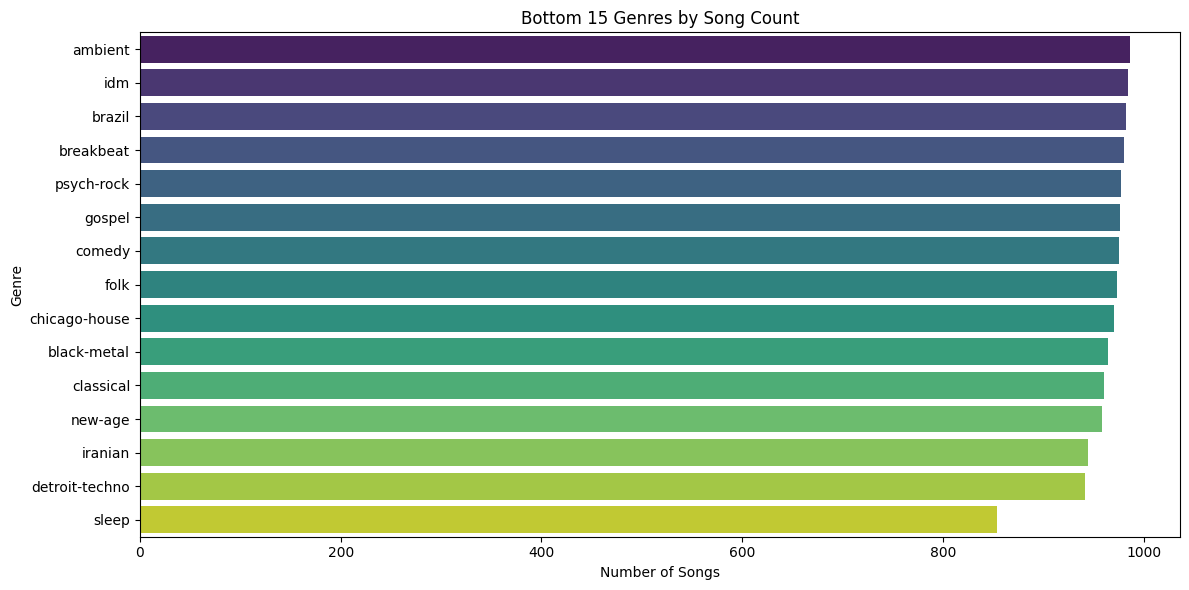

In [7]:
#看最少歌曲的15個流派
bottom_genres = df['track_genre'].value_counts().tail(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=bottom_genres.values,
            y=bottom_genres.index,
            hue=bottom_genres.index,
            palette='viridis',
            legend=False)
plt.title('Bottom 15 Genres by Song Count')  # 歌曲最少的15個流派
plt.xlabel('Number of Songs')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

In [8]:
# 從 scikit-learn 引入我們需要的工具
from sklearn.preprocessing import StandardScaler      # 標準化數值
from sklearn.metrics.pairwise import cosine_similarity # 計算相似度

# 選取我們要用來比較歌曲的特徵欄位
# 這些都是音樂的"個性"數值
features = [
    'danceability',    # 舞蹈性
    'energy',          # 能量
    'loudness',        # 響度
    'speechiness',     # 語音程度
    'acousticness',    # 原聲程度
    'instrumentalness',# 純音樂程度
    'liveness',        # 現場感
    'valence',         # 情緒正面程度
    'tempo'            # 速度BPM
]

# 把這些欄位從dataframe取出來
# 存成一個新的變數 X
X = df[features]

# 確認取出的資料大小
print(f"特徵矩陣大小: {X.shape}")
print(f"\n前5筆資料：")
print(X.head())

特徵矩陣大小: (113241, 9)

前5筆資料：
   danceability  energy  loudness  speechiness  acousticness  \
0         0.676  0.4610    -6.746       0.1430        0.0322   
1         0.420  0.1660   -17.235       0.0763        0.9240   
2         0.438  0.3590    -9.734       0.0557        0.2100   
3         0.266  0.0596   -18.515       0.0363        0.9050   
4         0.618  0.4430    -9.681       0.0526        0.4690   

   instrumentalness  liveness  valence    tempo  
0          0.000001    0.3580    0.715   87.917  
1          0.000006    0.1010    0.267   77.489  
2          0.000000    0.1170    0.120   76.332  
3          0.000071    0.1320    0.143  181.740  
4          0.000000    0.0829    0.167  119.949  


In [9]:
# StandardScaler 把所有欄位都縮放到同一尺度
# 平均值=0, 標準差=1
# 這樣每個特徵對相似度的貢獻是平等的！

scaler = StandardScaler()  # 建立標準化工具

# fit_transform = 學習數值範圍 + 轉換
X_scaled = scaler.fit_transform(X)

# 確認標準化結果
print(f"標準化後的矩陣大小: {X_scaled.shape}")
print(f"\n標準化前 tempo 範圍: {X['tempo'].min():.2f} ~ {X['tempo'].max():.2f}")
print(f"標準化後 tempo 範圍: {X_scaled[:, 8].min():.2f} ~ {X_scaled[:, 8].max():.2f}")

標準化後的矩陣大小: (113241, 9)

標準化前 tempo 範圍: 30.20 ~ 243.37
標準化後 tempo 範圍: -3.11 ~ 4.08


In [13]:
# 重新定義函數，加入 artist 參數
def get_recommendations(track_name, df, X_scaled, artist=None, n=10):
    df = df.reset_index(drop=True)
    
    # 先搜尋歌曲名稱
    matches = df[df['track_name'].str.lower() == track_name.lower()]
    
    # 如果有指定藝術家，再過濾
    if artist:
        matches = matches[matches['artists'].str.lower().str.contains(artist.lower())]
    
    if matches.empty:
        print(f"找不到歌曲：{track_name}")
        return None
    
    idx = matches.index[0]
    print(f"✅ 找到歌曲：{df.loc[idx, 'track_name']} - {df.loc[idx, 'artists']}")
    
    song_vector = X_scaled[idx].reshape(1, -1)
    sim_scores = cosine_similarity(song_vector, X_scaled)[0]
    sim_indices = sim_scores.argsort()[::-1]
    sim_indices = sim_indices[1:n+1]
    
    recommendations = df.loc[sim_indices, ['track_name', 'artists', 'track_genre']].copy()
    recommendations['similarity'] = sim_scores[sim_indices].round(3)
    recommendations = recommendations.reset_index(drop=True)
    recommendations.index += 1
    
    return recommendations

In [14]:
results = get_recommendations(
    track_name="Shape of You",
    df=df,
    X_scaled=X_scaled,
    artist="Ed Sheeran",   # ← 加上藝術家！
    n=10
)
print("\n🎵 推薦歌曲：")
print(results)

✅ 找到歌曲：Shape of You - Ed Sheeran

🎵 推薦歌曲：
                  track_name                       artists track_genre  \
1                       Tene           Larry Gaaga;Flavour   dancehall   
2                      Yaaro             Santesh;Amos Paul       malay   
3                   Brujeria  El Gran Combo De Puerto Rico       salsa   
4           Go-Go Club - Raw                   Vybz Kartel     j-dance   
5            Pop the Bubbles                  Patty Shukla        kids   
6   Separemos Nuestras Vidas                  Jerry Rivera       salsa   
7            Quiero Llenarte                  Jerry Rivera       salsa   
8                        Low            Larry Gaaga;Wizkid   dancehall   
9                    Pull Up              Timaya;Burna Boy   dancehall   
10                  Whine It                Jahyanai;Timal   dancehall   

    similarity  
1        0.977  
2        0.976  
3        0.976  
4        0.976  
5        0.975  
6        0.974  
7        0.972  
8      

In [ ]:
import openai
import os

os.environ["OPENAI_API_KEY"] = "sk-YOUR_API_KEY_HERE" 

# 然後讀取
openai.api_key = os.getenv("OPENAI_API_KEY")

# 確認
if openai.api_key:
    print("✅ API Key 設定成功！")
else:
    print("❌ 找不到 API Key！")

✅ API Key 設定成功！


In [17]:
def explain_recommendation(input_song, input_artist, recommended_song, recommended_artist, df):
    
    # 從資料集找出兩首歌的特徵
    input_features = df[
        (df['track_name'].str.lower() == input_song.lower()) &
        (df['artists'].str.lower().str.contains(input_artist.lower()))
    ][features].iloc[0]
    
    recommended_features = df[
        df['track_name'].str.lower() == recommended_song.lower()
    ][features].iloc[0]
    
    # 把特徵整理成文字給 AI 看
    prompt = f"""
    你是一個音樂推薦專家。
    
    使用者喜歡：{input_song} by {input_artist}
    這首歌的特徵：
    - 舞蹈性 (danceability): {input_features['danceability']:.2f}
    - 能量 (energy): {input_features['energy']:.2f}
    - 情緒正面程度 (valence): {input_features['valence']:.2f}
    - 原聲程度 (acousticness): {input_features['acousticness']:.2f}
    - 速度 (tempo): {input_features['tempo']:.1f} BPM
    
    我們推薦：{recommended_song} by {recommended_artist}
    這首歌的特徵：
    - 舞蹈性 (danceability): {recommended_features['danceability']:.2f}
    - 能量 (energy): {recommended_features['energy']:.2f}
    - 情緒正面程度 (valence): {recommended_features['valence']:.2f}
    - 原聲程度 (acousticness): {recommended_features['acousticness']:.2f}
    - 速度 (tempo): {recommended_features['tempo']:.1f} BPM
    
    請用2-3句話解釋為什麼推薦這首歌，用輕鬆友善的語氣！
    """
    
    # 呼叫 OpenAI API
    client = openai.OpenAI()
    response = client.chat.completions.create(
        model="gpt-4o-mini",   # 便宜又夠用！
        messages=[
            {"role": "user", "content": prompt}
        ],
        max_tokens=150          # 限制回覆長度
    )
    
    return response.choices[0].message.content

In [19]:
# Step 1 — 先取得推薦結果
results = get_recommendations(
    track_name="Shape of You",
    df=df,
    X_scaled=X_scaled,
    artist="Ed Sheeran",
    n=10
)

print("\n🎵 推薦歌曲：")
print(results)

# Step 2 — 對 Top 3 做 AI 解釋
print("\n\n🤖 AI 解釋為什麼推薦這些歌：")
print("="*50)

for i in range(1, 4):  # 只解釋前3首
    rec_song = results.loc[i, 'track_name']
    rec_artist = results.loc[i, 'artists']
    
    print(f"\n#{i} {rec_song} - {rec_artist}")
    print("-"*40)
    
    explanation = explain_recommendation(
        input_song="Shape of You",
        input_artist="Ed Sheeran",
        recommended_song=rec_song,
        recommended_artist=rec_artist,
        df=df
    )
    
    print(explanation)
    print("="*50)

✅ 找到歌曲：Shape of You - Ed Sheeran

🎵 推薦歌曲：
                  track_name                       artists track_genre  \
1                       Tene           Larry Gaaga;Flavour   dancehall   
2                      Yaaro             Santesh;Amos Paul       malay   
3                   Brujeria  El Gran Combo De Puerto Rico       salsa   
4           Go-Go Club - Raw                   Vybz Kartel     j-dance   
5            Pop the Bubbles                  Patty Shukla        kids   
6   Separemos Nuestras Vidas                  Jerry Rivera       salsa   
7            Quiero Llenarte                  Jerry Rivera       salsa   
8                        Low            Larry Gaaga;Wizkid   dancehall   
9                    Pull Up              Timaya;Burna Boy   dancehall   
10                  Whine It                Jahyanai;Timal   dancehall   

    similarity  
1        0.977  
2        0.976  
3        0.976  
4        0.976  
5        0.975  
6        0.974  
7        0.972  
8      